In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [30]:
from jarvis.db.figshare import data
mxene_data = data("mxene275")
df = pd.DataFrame(mxene_data)
df["formula"] = df["id"].str.replace("POSCAR-", "").str.replace(".vasp", "")

existing_formulas = set(df["formula"])
candidate = "Mo2TiC2"
print(candidate in existing_formulas)  # False berarti kandidat baru


Obtaining mxene dataset 275...
Reference:https://cmr.fysik.dtu.dk/c2db/c2db.html
Loading the zipfile...
Loading completed.
False


In [56]:
RY2EV = 13.6056980659

# referensi per atom (eV), dari total energy bulk/molekul ÷ jumlah atom
ref_per_atom_eV = {
    "Ti": -551.15798273 / 3 * RY2EV,
    "Mo": -727.56253225 / 2 *RY2EV, 
    "Zr": -614.44602867 / 2 * RY2EV,
    "C":  -73.77270849  / 4 * RY2EV,
    "O":  -83.03796947  / 2 * RY2EV,   # versi molekul O2
    "H":  -2.33319538   / 2 * RY2EV,   # versi molekul H2
}

def compute_formation_energy(total_energy_Ry, composition_dict):
    """composition_dict misal {'Ti':2,'C':1,'O':2,'H':2}"""
    E_total_eV = total_energy_Ry * RY2EV
    E_ref = sum(n * ref_per_atom_eV[el] for el, n in composition_dict.items())
    n_atom = sum(composition_dict.values())
    return (E_total_eV - E_ref) / n_atom

In [57]:
qe_results = [
    {"formula": "Ti2CH2O2", "formation_energy_dft": compute_formation_energy(-471.93046322, {"Ti":2,"C":1,"O":2,"H":2})},
    {"formula": "Zr2CH2O2", "formation_energy_dft": compute_formation_energy(-718.91105126, {"Zr":2,"C":1,"O":2,"H":2})},
    {"formula": "Mo2TiC2", "formation_energy_dft": compute_formation_energy(-948.39339776, {"Mo":2,"Ti":1,"C":2})},
]

qe_df = pd.DataFrame(qe_results)
qe_df.to_csv("data/dft_validation/formation_energy_qe.csv", index=False)
qe_df


,formula,formation_energy_dft
0,Ti2CH2O2,-1.316771
1,Zr2CH2O2,-1.264709
2,Mo2TiC2,-0.612756


In [58]:
from matminer.featurizers.composition import ElementProperty
from pymatgen.core import Composition

ep = ElementProperty.from_preset(preset_name="magpie")

In [59]:
pred_df = pd.read_csv("data/processed/predictions_all.csv")
merged = pd.merge(pred_df, qe_df, on="formula")
merged["error"] = merged["formation_energy_pred"] - merged["formation_energy_dft"]


In [60]:
# Contoh format CSV hasil QE
# columns: formula, total_energy, formation_energy_dft
qe_df = pd.read_csv("data/dft_validation/formation_energy_qe.csv")


In [61]:
import joblib
from pymatgen.core import Composition

model = joblib.load("src/model_rf.joblib")

def predict_formation_energy(formula_str):
    comp = Composition(formula_str)
    row = pd.DataFrame({"composition": [comp]})
    row_feat = ep.featurize_dataframe(row, "composition", ignore_errors=True)
    X_new = row_feat[model.feature_names_in_]
    return model.predict(X_new)[0]

qe_df["formation_energy_pred"] = qe_df["formula"].apply(predict_formation_energy)
qe_df["error"] = qe_df["formation_energy_pred"] - qe_df["formation_energy_dft"]
qe_df.to_csv("data/dft_validation/comparison.csv", index=False)
qe_df

ElementProperty: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 11.97it/s]


,formula,formation_energy_dft,formation_energy_pred,error
0,Ti2CH2O2,-1.316771,-1.426902,-0.110131
1,Zr2CH2O2,-1.264709,-1.436210,-0.171501
2,Mo2TiC2,-0.612756,0.008647,0.621403


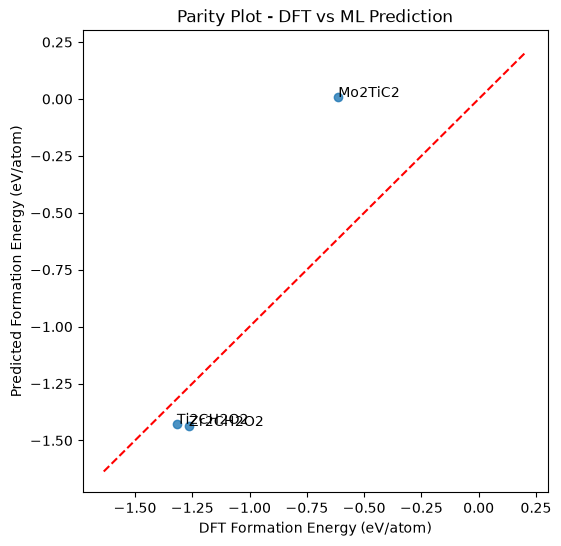

MAE: 0.301 eV/atom  (3 titik)


In [62]:
plt.figure(figsize=(6,6))
plt.scatter(qe_df["formation_energy_dft"], qe_df["formation_energy_pred"], alpha=0.8)
lims = [qe_df[["formation_energy_dft","formation_energy_pred"]].min().min() - 0.2,
        qe_df[["formation_energy_dft","formation_energy_pred"]].max().max() + 0.2]
plt.plot(lims, lims, "r--")
for _, row in qe_df.iterrows():
    plt.annotate(row["formula"], (row["formation_energy_dft"], row["formation_energy_pred"]))
plt.xlabel("DFT Formation Energy (eV/atom)")
plt.ylabel("Predicted Formation Energy (eV/atom)")
plt.title("Parity Plot - DFT vs ML Prediction")
plt.show()

mae = np.mean(np.abs(qe_df["error"]))
print(f"MAE: {mae:.3f} eV/atom  ({len(qe_df)} titik)")